<img src="https://www.unir.net/wp-content/uploads/2019/11/Unir_2021_logo.svg" width="240" height="240" align="right"/>

<center><h1>Técnicas de Inteligencia Artificial</header1></center>
<left><h1>Actividad 2. Trabajando con redes neuronales y Deep Learning</header1></left>

# Importación de librerias necesarias

In [1]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesado, división de datos, modelo no basado en redes neuronales y métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Red neuronal con Keras sobre TensorFlow 2.0
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Para que los resultados sean reproducibles 
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Ajustes viasuales para gráficas
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('TensorFlow:', tf.__version__)
print('Pandas:', pd.__version__)

TensorFlow: 2.21.0
Pandas: 2.3.3


# Parte II. Clasificación

## Cargar el Dataset

Tal y como se pide en el enunciado del proyecto, ingererimos el dataset de forma automática, paro ello, hemos creado un repositorio público en GitHub. Además, este cuenta con al menos, una variable categórica de al menos cinco clases posibles a la salida, y que depende de, al menos, seis variables/atributos de entrada.

In [2]:
# Código para cargar el Dataset

url = 'https://raw.githubusercontent.com/fernandoespinasv/regreclas-tecnicasIA-UNIR/refs/heads/main/ObesityDataSet_raw_and_data_sinthetic.csv'

df = pd.read_csv(url)
print(f'Dataset cargado correctamente: {df.shape[0]} filas, {df.shape[1]} columnas.')
df.head()

Dataset cargado correctamente: 2111 filas, 17 columnas.


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## Descripción de la fuente del Dataset

El dataset propuesto ha sido extraído de la plataforma online de **Kaggle** (https://www.kaggle.com/datasets/ankurbajaj9/obesity-levels) y procede originalmente del estudio publicado por Palechor & de la Hoz Manotas (2019), disponible también en el UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/544/). Los autores recogieron información sobre los hábitos alimenticios y la condición física de individuos de Colombia, Perú y México. Destacar que aproximadamente el 77% de los registros del dataset fueron generados con la técnica SMOTE para equilibrar las clases.

Contiene un total de **2.111 instancias** con 17 atributos cada una, incluyendo información personal (género, edad), medidas físicas (altura, peso), hábitos alimenticios (frecuencia de consumo de verduras, número de comidas, etc.) y hábitos de vida (actividad física, transporte, consumo de tabaco y alcohol).

## Explique el problema a resolver

Nuestro problema a resolver es un problema de aprendizaje supervisado de **clasificación multiclase**: nuestra variable objetivo será `NObeyesdad`, que es categórica y toma 7 valores distintos que se corresponden con los niveles de obesidad (`Insufficient_Weight`, `Normal_Weight`, `Overweight_Level_I`, `Overweight_Level_II`, `Obesity_Type_I`, `Obesity_Type_II`, `Obesity_Type_III`); mientras que nuestras variables de entrada serán los distintos atributos sobre hábitos alimenticios y condición física.

Antes de listarlas, tenemos que tomar una **decisión importante**: vamos a **eliminar las variables `Height` y `Weight`** del dataset. La razón es que `NObeyesdad` se calcula a partir del IMC (`Weight` / `Height`²), por lo que esas dos columnas determinan la clase por completo. Si las dejamos, el problema sería trivial y sin valor práctico. Quitándolas, el reto se convierte en algo mucho más útil: **predecir el riesgo de obesidad solo y exclusivamente a partir de los hábitos**.

De este modo, nos quedan 14 atributos de entrada (más que suficientes según el mínimo de 6 que pide el enunciado):

| Variable | Descripción | Tipo |
|---|---|---|
| `Gender` | Género (Male/Female) | Categórica |
| `Age` | Edad | Numérica |
| `family_history_with_overweight` | Antecedentes familiares de sobrepeso (yes/no) | Categórica |
| `FAVC` | Consumo frecuente de comida muy calórica (yes/no) | Categórica |
| `FCVC` | Frecuencia de consumo de verduras | Numérica (1–3) |
| `NCP` | Número de comidas principales al día | Numérica (1–4) |
| `CAEC` | Consumo entre comidas (no/Sometimes/Frequently/Always) | Categórica |
| `SMOKE` | Fuma (yes/no) | Categórica |
| `CH2O` | Litros de agua al día | Numérica (1–3) |
| `SCC` | Monitorización de calorías (yes/no) | Categórica |
| `FAF` | Frecuencia de actividad física | Numérica (0–3) |
| `TUE` | Tiempo usando dispositivos electrónicos | Numérica (0–2) |
| `CALC` | Consumo de alcohol (no/Sometimes/Frequently/Always) | Categórica |
| `MTRANS` | Medio de transporte | Categórica |

Destacar que un modelo de este tipo podría ser muy útil en atención primaria o programas de salud pública, permitiendo identificar personas con riesgo de obesidad a partir de un breve cuestionario sobre hábitos.

**Lo que queremos comprobar** es si solo con la información sobre hábitos podemos predecir con buena precisión el nivel de obesidad, y si una red neuronal mejora claramente a un modelo más simple como una regresión logística multinomial. Esta última la elegimos como **modelo alternativo no basado en redes neuronales**, ya que es el modelo de referencia clásico para clasificación multiclase y nos servirá como buen *baseline*.

## Caracterización del Dataset

Realizamos una descripción de los datos con:

>- Número de instancias en total.
>- Número de atributos de entrada, su significado y tipo.
>- Estadísticas de la variable objetivo.
>- Estadísticas de los atributos en relación con la variable objetivo.


In [3]:
# Vistazo general del dataset

print('Instancias y atributos:', df.shape)
print('\nTipos de datos:')
df.info()

Instancias y atributos: (2111, 17)

Tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-nu

Vemos que hay **2.111 instancias** y **17 columnas**, una mezcla de `object` (categóricas) y numéricas (`float64`/`int64`). No hay valores nulos en ninguna columna (todas tienen 2.111 valores no nulos), así que en el preprocesado no tendremos que tratar imputaciones.

In [4]:
# Análisis descriptivo de las variables numéricas

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FCVC,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NCP,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
CH2O,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FAF,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TUE,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00


Lo que más llama la atención: `Age` va de 14 a 61 años con media en torno a 24, mientras que el resto de variables numéricas están en rangos mucho más pequeños (1-3 o 0-3). Al igual que en el primer notebook, esto nos obliga a **normalizar antes de entrenar la red neuronal**.

C:\Users\Fernando\AppData\Local\Temp\ipykernel_10788\4190302690.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='NObeyesdad', order=orden_clases,


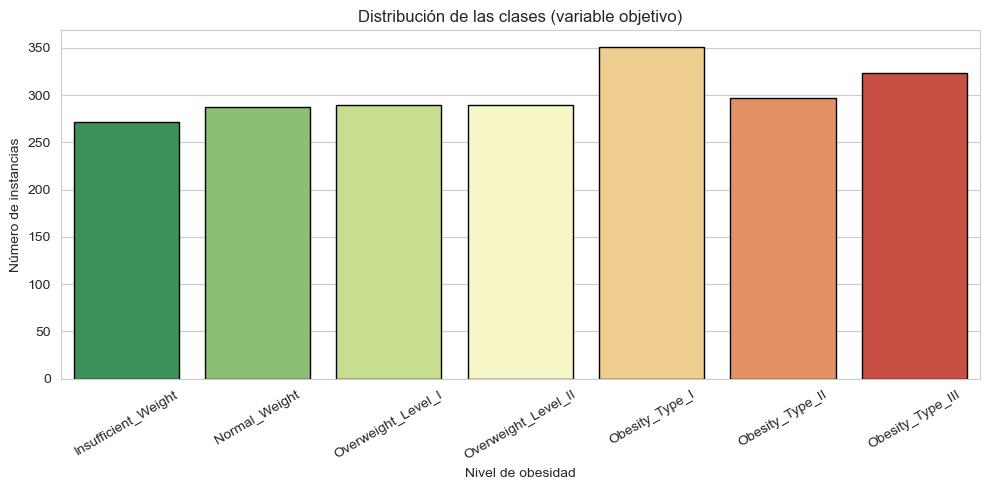


Número de instancias por clase:
NObeyesdad
Insufficient_Weight    272
Normal_Weight          287
Overweight_Level_I     290
Overweight_Level_II    290
Obesity_Type_I         351
Obesity_Type_II        297
Obesity_Type_III       324
Name: count, dtype: int64


In [5]:
# Distribución de la variable objetivo

fig, ax = plt.subplots(figsize=(10, 5))

# Defino el orden lógico de las clases (de menor a mayor peso) para que el gráfico sea legible
orden_clases = ['Insufficient_Weight', 'Normal_Weight',
                'Overweight_Level_I', 'Overweight_Level_II',
                'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

sns.countplot(data=df, x='NObeyesdad', order=orden_clases,
              palette='RdYlGn_r', edgecolor='black', ax=ax)
ax.set_title('Distribución de las clases (variable objetivo)')
ax.set_xlabel('Nivel de obesidad')
ax.set_ylabel('Número de instancias')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('distribución_clases.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNúmero de instancias por clase:')
print(df['NObeyesdad'].value_counts().reindex(orden_clases))

Aquí vemos algo MUY importante: la variable objetivo está bien equilibrada. Las 7 clases tienen entre 270 y 350 instancias cada una, sin desbalance notable. Esto es algo muy bueno ya que no vamos a tener que aplicar técnicas de balanceo (oversampling, class weights, etc.) y las métricas como la accuracy serán fiables. Esto además es acorde con el hecho de que el dataset fue equilibrado con SMOTE por los autores.

C:\Users\Fernando\AppData\Local\Temp\ipykernel_10788\2733705613.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='NObeyesdad', y=var, order=orden_clases,
C:\Users\Fernando\AppData\Local\Temp\ipykernel_10788\2733705613.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='NObeyesdad', y=var, order=orden_clases,
C:\Users\Fernando\AppData\Local\Temp\ipykernel_10788\2733705613.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='NObeyesdad', y=var, order=orden_clases,
C:\Users\Fernando\AppData\Local\Temp\ipyker

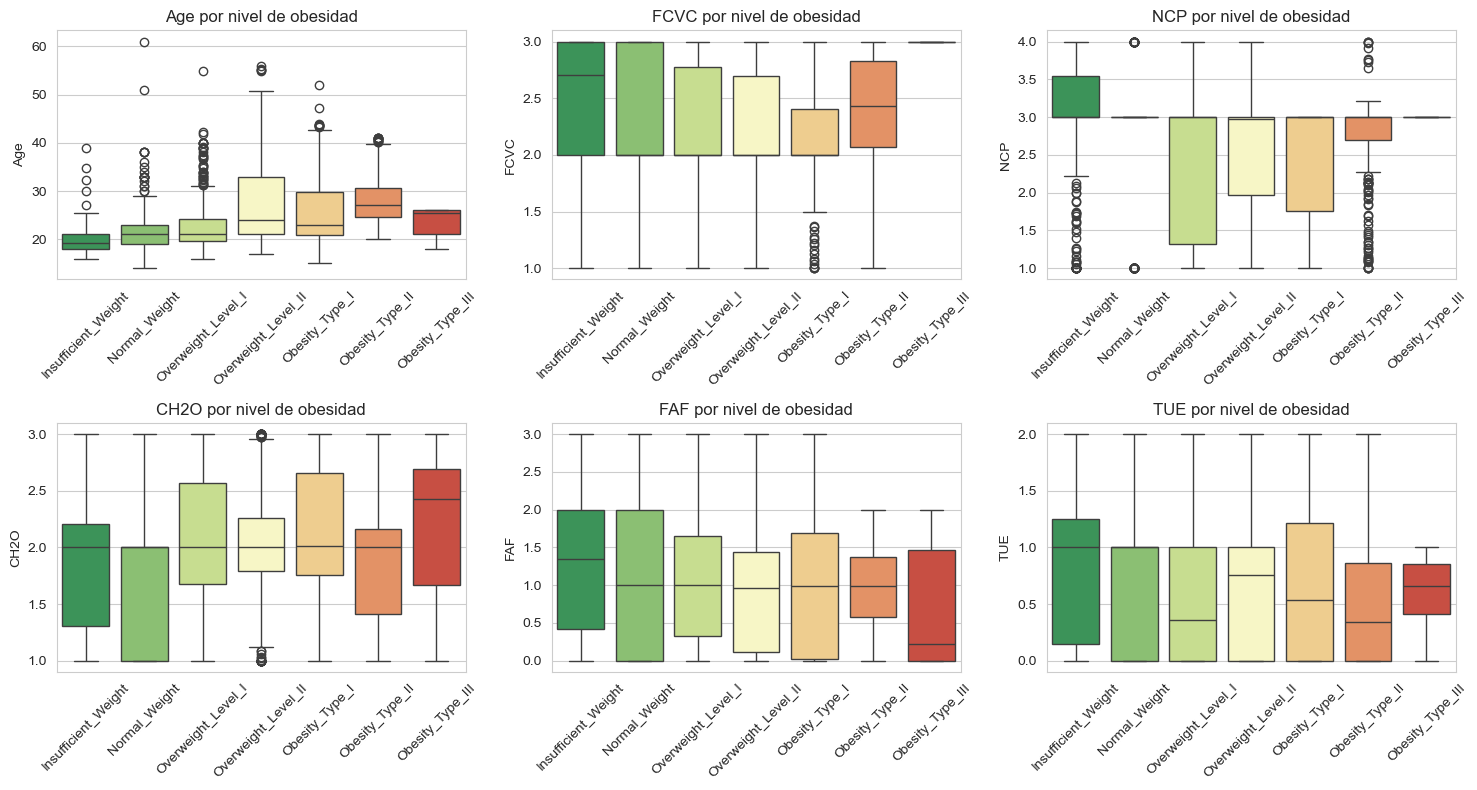

In [6]:
# Relación entre variables numéricas y nivel de obesidad

variables_num = ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(variables_num):
    sns.boxplot(data=df, x='NObeyesdad', y=var, order=orden_clases,
                palette='RdYlGn_r', ax=axes[i])
    axes[i].set_title(f'{var} por nivel de obesidad')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('numericas_vs_obesidad.png', dpi=150, bbox_inches='tight')
plt.show()

De aquí destacamos algunas cosas interesantes. La actividad física (`FAF`) **disminuye** claramente en los niveles de obesidad altos, lo cual era esperable. El tiempo en dispositivos electrónicos (`TUE`) también muestra cierta tendencia (los más jóvenes con obesidad pasan más tiempo en pantallas). `Age` tiene comportamientos distintos según el nivel: los niveles intermedios tienden a edades más altas. El resto de variables (`FCVC`, `NCP`, `CH2O`) son más parecidas entre clases, aunque con matices.

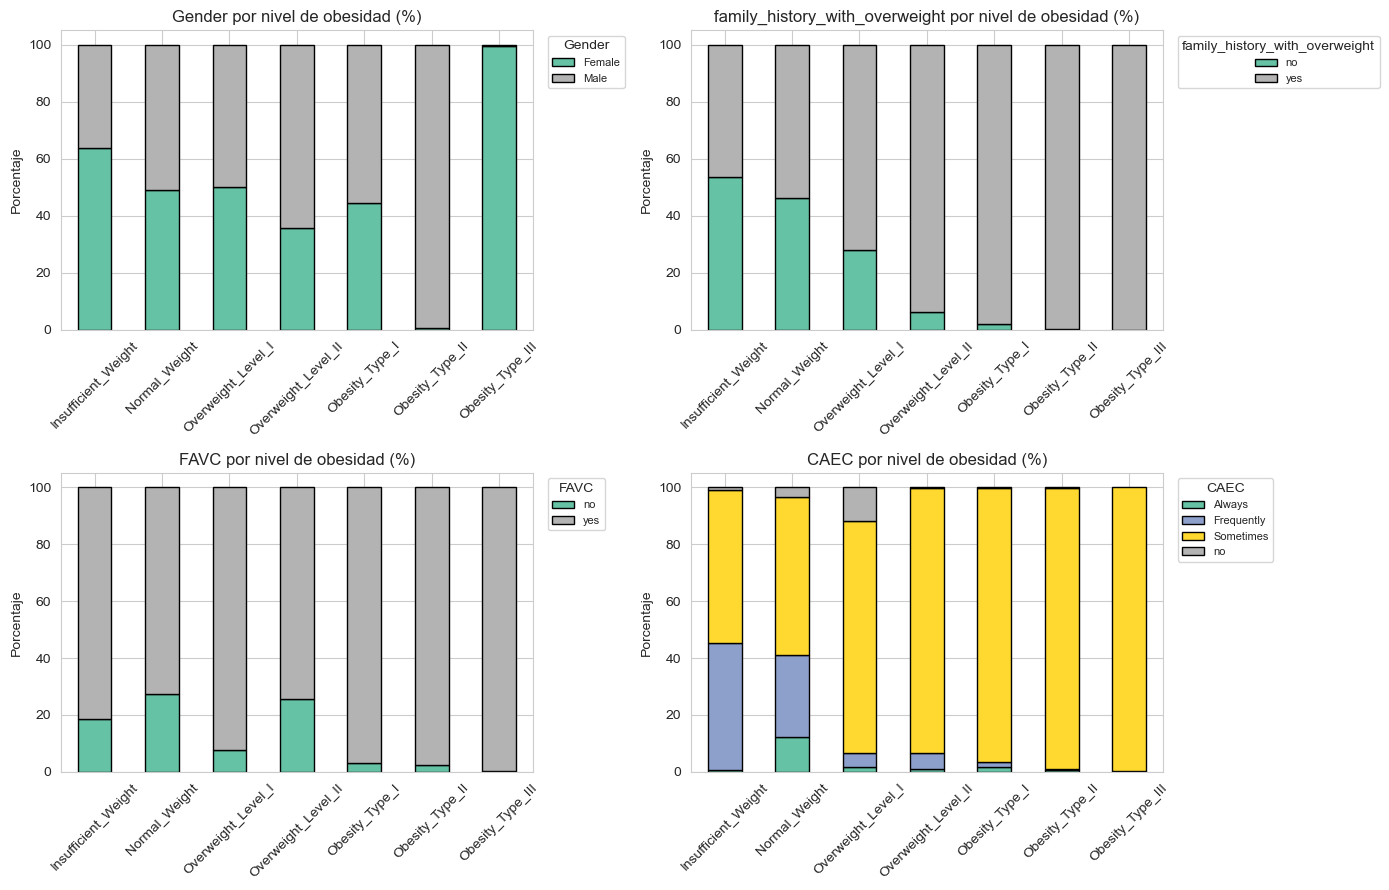

In [7]:
# Relación entre variables categóricas y nivel de obesidad

variables_cat = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, var in enumerate(variables_cat):
    # Crosstab normalizado: cada fila suma 100% (porcentaje de cada clase dentro del nivel de obesidad)
    cross = pd.crosstab(df['NObeyesdad'], df[var], normalize='index') * 100
    cross = cross.reindex(orden_clases)
    cross.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2', edgecolor='black')
    axes[i].set_title(f'{var} por nivel de obesidad (%)')
    axes[i].set_ylabel('Porcentaje')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title=var, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('categoricas_vs_obesidad.png', dpi=150, bbox_inches='tight')
plt.show()

Lo más interesante aquí el hecho de que **`family_history_with_overweight`** prácticamente predice por sí sola los niveles altos de obesidad: en `Obesity_Type_II` y `Obesity_Type_III` casi todos tienen antecedentes familiares de sobrepeso, mientras que en `Insufficient_Weight` la mayoría no los tienen. `FAVC` (consumo frecuente de comida calórica) también muestra una relación clara. Esto nos da una idea de qué variables van a ser las más determinantes para nuestro modelo.  

### Resumen de los principales hallazgos del EDA

1. **Tamaño:** 2.111 instancias y 17 atributos (con `Height` y `Weight` que vamos a eliminar).
2. **Variable objetivo equilibrada:** las 7 clases tienen entre 270 y 350 instancias cada una.
3. **Escalas distintas:** `Age` va hasta 61 mientras que el resto de numéricas está en rangos pequeños (1-3, 0-3). Habrá que normalizar.
4. **Variables más informativas:** `family_history_with_overweight`, `FAVC` y `FAF` muestran relaciones claras con el nivel de obesidad.

## Preprocesamiento del dataset. Transformaciones previas necesarias para la modelación

Nuestro plan de preprocesado es:

1. Eliminar duplicados.
2. Descartar las columnas `Height` y `Weight` (por la razón explicada antes).
3. Codificar el target con `LabelEncoder` para convertir las 7 clases (strings) en enteros del 0 al 6.
4. Aplicar One-hot encoding a las variables categóricas de entrada.
5. Separar `X` (features) e `y` (target) y hacer el split train/test estratificado.
6. Escalar las features numéricas con `StandardScaler` (después del split para evitar fuga de información).
7. Convertir el target a formato one-hot con `to_categorical` para la red neuronal (la regresión logística no lo necesita).

In [8]:
# Primero eliminamos los duplicados

df_clean = df.drop_duplicates().reset_index(drop=True)

# Ahora descartamos Height y Weight por la razón comentada antes

df_clean = df_clean.drop(columns=['Height', 'Weight'])

print(f'Filas antes: {df.shape[0]}. Después de quitar duplicados: {df_clean.shape[0]}')
print('Columnas restantes:', list(df_clean.columns))

Filas antes: 2111. Después de quitar duplicados: 2087
Columnas restantes: ['Gender', 'Age', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


In [9]:
# Codificamos el target con LabelEncoder (de string a enteros 0-6)
# Guardamos el encoder para recuperar después los nombres originales al mostrar resultados

label_encoder = LabelEncoder()
df_clean['NObeyesdad_encoded'] = label_encoder.fit_transform(df_clean['NObeyesdad'])

print('Mapeo de clases (índice -> clase):')
for i, clase in enumerate(label_encoder.classes_):
    print(f'  {i} -> {clase}')

Mapeo de clases (índice -> clase):
  0 -> Insufficient_Weight
  1 -> Normal_Weight
  2 -> Obesity_Type_I
  3 -> Obesity_Type_II
  4 -> Obesity_Type_III
  5 -> Overweight_Level_I
  6 -> Overweight_Level_II


In [10]:
# Aplicamos One-hot encoding a las variables categóricas de entrada

# Identificamos las columnas categóricas (tipo object, sin contar el target ni su versión codificada)
cols_categoricas = df_clean.select_dtypes(include='object').columns.tolist()
cols_categoricas.remove('NObeyesdad')   # el target original no lo codificamos aquí
print(f'Columnas categóricas a las que aplicaremos One-hot: {cols_categoricas}')

# Con dtype=int evitamos que pandas devuelva columnas booleanas (True/False)
df_clean = pd.get_dummies(df_clean, columns=cols_categoricas, drop_first=False, dtype=int)

# Quitamos la columna del target original (string), nos quedamos con la versión codificada
df_clean = df_clean.drop(columns=['NObeyesdad'])

print('\nDataFrame tras el preprocesado:', df_clean.shape)
df_clean.head()

Columnas categóricas a las que aplicaremos One-hot: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

DataFrame tras el preprocesado: (2087, 30)


,Age,FCVC,NCP,CH2O,FAF,TUE,NObeyesdad_encoded,Gender_Female,Gender_Male,family_history_with_overweight_no,...,SCC_yes,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,2.0,3.0,2.0,0.0,1.0,1,1,0,0,...,0,0,0,0,1,0,0,0,1,0
1,21.0,3.0,3.0,3.0,3.0,0.0,1,1,0,0,...,1,0,0,1,0,0,0,0,1,0
2,23.0,2.0,3.0,2.0,2.0,1.0,1,0,1,0,...,0,0,1,0,0,0,0,0,1,0
3,27.0,3.0,3.0,2.0,2.0,0.0,5,0,1,1,...,0,0,1,0,0,0,0,0,0,1
4,22.0,2.0,1.0,2.0,0.0,0.0,6,0,1,1,...,0,0,0,1,0,0,0,0,1,0


In [11]:
# Separamos X (features) e y (target)

y = df_clean['NObeyesdad_encoded'].values
X = df_clean.drop(columns=['NObeyesdad_encoded']).values

# Guardamos los nombres de las features
feature_names = df_clean.drop(columns=['NObeyesdad_encoded']).columns.tolist()
n_clases = len(label_encoder.classes_)

# train_test_split estratificado para mantener la proporción de clases en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

X_train: (1669, 29)   y_train: (1669,)
X_test:  (418, 29)   y_test:  (418,)


In [12]:
# Normalizamos las features

scaler = StandardScaler()

# Con fit_transform calculamos media y desviación con train y aplicamos la transformación
X_train_scaled = scaler.fit_transform(X_train)

# Aplicamos a test la MISMA transformación anterior
X_test_scaled = scaler.transform(X_test)

# Pasamos el target a one-hot para la red neuronal (la regresión logística no lo necesita)
y_train_onehot = to_categorical(y_train, num_classes=n_clases)
y_test_onehot = to_categorical(y_test, num_classes=n_clases)

print('Datos escalados. Comprobamos que la media es ~0 y la desviación ~1 en train:')
print(f'  Media:      {X_train_scaled.mean():.4f}')
print(f'  Desviación: {X_train_scaled.std():.4f}')
print(f'\nForma del target one-hot: {y_train_onehot.shape}')

Datos escalados. Comprobamos que la media es ~0 y la desviación ~1 en train:
  Media:      -0.0000
  Desviación: 1.0000

Forma del target one-hot: (1669, 7)


## División del dataset en datos de entrenamiento y datos de test 

Esta parte la hemos hecho en el anterior apartado.

## Propuesta de arquitectura de red neuronal

La arquitectura que propongo es un **MLP (Multi-Layer Perceptron)**, una red densa clásica:

| Capa | Tipo | Neuronas | Activación | Por qué |
|---|---|---|---|---|
| Entrada | Input | tantas como features | — | una neurona por cada variable de entrada |
| Oculta 1 | Dense | 64 | ReLU | suficiente capacidad para aprender patrones no lineales |
| — | Dropout | — (30%) | — | regularización: apaga el 30% de neuronas en cada paso para evitar sobreajuste |
| Oculta 2 | Dense | 32 | ReLU | reduzco neuronas en capas más profundas (esquema típico de "embudo") |
| Salida | Dense | 7 | Softmax | porque es clasificación multiclase: devuelve una probabilidad por cada una de las 7 clases |

**Activación ReLU** (`max(0, x)`): es la activación más usada en capas ocultas. Es rápida y evita el problema del *vanishing gradient* que tenían las activaciones tipo sigmoide.

**Activación Softmax en la salida:** es la activación obligatoria en clasificación multiclase con `categorical_crossentropy`. Convierte las salidas en una distribución de probabilidad (7 valores que suman 1). La clase predicha será la del valor más alto.

**Dropout del 30%** (frente al 20% que usábamos en regresión): subimos el dropout porque aquí tenemos bastantes menos datos (2.000 frente a 32.000 canciones) y por tanto, hay más riesgo de sobreajuste.

**Loss = categorical_crossentropy:** la función de pérdida estándar en clasificación multiclase con target one-hot. Mide la diferencia entre la distribución predicha y la real. El modelo intenta minimizarla.

**Optimizador = Adam:** combina las ventajas de varios optimizadores y suele funcionar bien. Es el más usado por defecto.

**Métrica adicional = accuracy:** porcentaje de aciertos. Es la métrica más intuitiva en clasificación, y como las clases están equilibradas, es fiable.

In [13]:
# Definimos el modelo capa por capa con la API Sequential

model_nn = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),     # capa de entrada (una neurona por feature)
    Dense(64, activation='relu'),                 # 1ª capa oculta: 64 neuronas con ReLU
    Dropout(0.3),                                 # apaga el 30% de neuronas cada paso
    Dense(32, activation='relu'),                 # 2ª capa oculta: 32 neuronas con ReLU
    Dense(n_clases, activation='softmax')         # capa de salida: 7 neuronas con softmax
])

# Compilar = configurar cómo se va a entrenar la red
model_nn.compile(
    optimizer='adam',                     # algoritmo de optimización
    loss='categorical_crossentropy',      # función de pérdida que el modelo minimiza
    metrics=['accuracy']                  # métricas que quiero ver durante el entrenamiento
)

# .summary() muestra la estructura de la red y cuántos parámetros entrenables tiene cada capa.
model_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,231 (16.53 KB)

 Trainable params: 4,231 (16.53 KB)

 Non-trainable params: 0 (0.00 B)

##  Ajuste de modelo de Clasificación RNA

Mediante Python y Keras sobre TensorFlow 2.0 (`tensorflow.keras`), entreno el modelo. Algunos detalles del entrenamiento:

- **Epochs:** ponemos 200 como máximo, aunque el `EarlyStopping` parará antes si la pérdida de validación deja de mejorar.
- **Batch size:** los pesos se actualizan cada 32 muestras (mini-batch). Lo bajo respecto al primer notebook (allí era 64) porque tenemos menos datos.
- **Validation split:** un 20% de los datos de train se reserva como validación durante el entrenamiento (el modelo NO entrena con ellos, solo los usa para vigilar el sobreajuste).
- **EarlyStopping:** detiene el entrenamiento si `val_loss` no mejora durante 15 epochs seguidas (un poco más de paciencia que en regresión porque con menos datos la curva es más ruidosa) y restaura los pesos del mejor punto visto.

In [14]:
# Callback de EarlyStopping para parar el entrenamiento cuando deje de mejorar

early_stop = EarlyStopping(
    monitor='val_loss',           # vigilamos la pérdida en validación
    patience=15,                   # cuántas epochs aguantar sin mejora antes de parar
    restore_best_weights=True,     # al parar, restaura los mejores pesos vistos
    verbose=1
)

# .fit() entrena la red y devuelve un objeto 'history' con la evolución de las métricas por epoch

history = model_nn.fit(
    X_train_scaled, y_train_onehot,
    validation_split=0.20,         # 20% de train para validación
    epochs=200,                     # máximo de epochs (parará antes con EarlyStopping)
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2097 - loss: 1.9112 - val_accuracy: 0.3952 - val_loss: 1.7359
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4300 - loss: 1.6132 - val_accuracy: 0.4790 - val_loss: 1.4701
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5109 - loss: 1.3676 - val_accuracy: 0.5569 - val_loss: 1.2642
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5760 - loss: 1.1896 - val_accuracy: 0.5868 - val_loss: 1.1606
Epoch 5/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5993 - loss: 1.1164 - val_accuracy: 0.5958 - val_loss: 1.1092
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6307 - loss: 1.0540 - val_accuracy: 0.5988 - val_loss: 1.0713
Epoch 7/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6262 - loss: 1.0268 - val_accuracy: 0.6078 - val_loss: 1.0464
Epoch 8/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6494 - loss: 0.9754 - val_accuracy: 0.6228 - 

## Evaluación de modelo RNA

Las métricas que vamos a usar para la evaluación del modelo son las siguientes:

- **Accuracy:** porcentaje de aciertos. Es la métrica más intuitiva en clasificación.
- **F1 macro:** media del F1-score (combinación de precisión y recall) calculado por separado en cada clase y luego promediada. Da el mismo peso a todas las clases, así que si el modelo va mal en una clase concreta, el F1 macro lo refleja.
- **Classification report:** tabla con precisión, recall y F1 por cada clase. Útil para detectar si el modelo falla en alguna clase concreta.
- **Matriz de confusión:** una tabla cuadrada donde la fila es la clase real y la columna la predicha. La diagonal son los aciertos; fuera de la diagonal, los errores. Permite ver entre qué clases se confunde el modelo.


### Visualice el progreso de entrenamiento del modelo y muestre las estadísticas de evaluación para los conjuntos de entrenamiento y validación.  

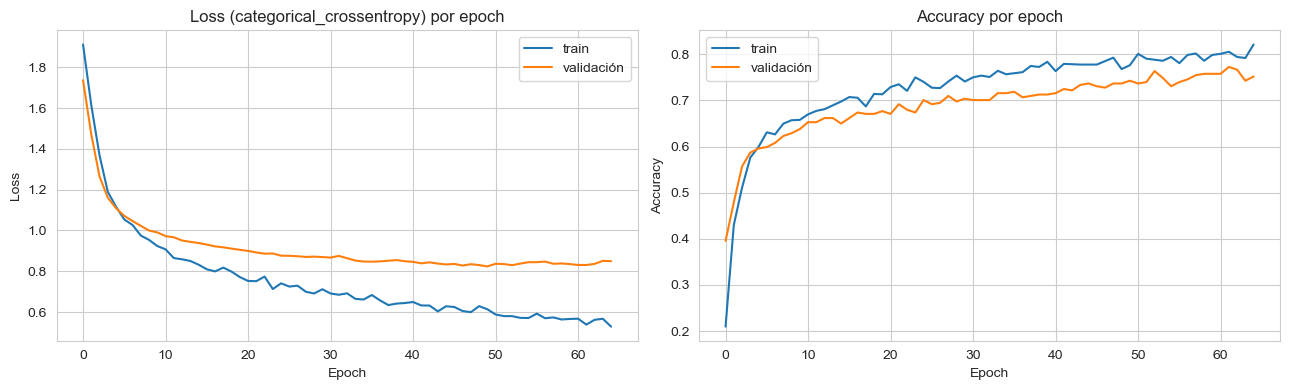

Métricas finales tras el entrenamiento:
  Train      - loss: 0.5291  accuracy: 0.8210
  Validación - loss: 0.8497  accuracy: 0.7515


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Curva de loss (categorical_crossentropy)
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='validación')
axes[0].set_title('Loss (categorical_crossentropy) por epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

# Curva de accuracy
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='validación')
axes[1].set_title('Accuracy por epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('curvas_entrenamiento_nn.png', dpi=120, bbox_inches='tight')
plt.show()

# Métricas finales (último valor de cada lista)
print(f'Métricas finales tras el entrenamiento:')
print(f'  Train      - loss: {history.history["loss"][-1]:.4f}  accuracy: {history.history["accuracy"][-1]:.4f}')
print(f'  Validación - loss: {history.history["val_loss"][-1]:.4f}  accuracy: {history.history["val_accuracy"][-1]:.4f}')

### Evalúe los resultados  para el conjunto de test.

In [16]:
# Predicciones sobre test. model.predict devuelve probabilidades (n_samples, 7).
# np.argmax sobre axis=1 nos da la clase con la probabilidad más alta para cada muestra.

y_pred_proba_nn = model_nn.predict(X_test_scaled, verbose=0)
y_pred_nn = np.argmax(y_pred_proba_nn, axis=1)

# Calculamos las métricas
acc_nn = accuracy_score(y_test, y_pred_nn)
f1_nn  = f1_score(y_test, y_pred_nn, average='macro')

print(f'Red neuronal — Accuracy: {acc_nn:.4f}')
print(f'Red neuronal — F1 macro: {f1_nn:.4f}')
print()
print('Classification report (red neuronal):')
print(classification_report(y_test, y_pred_nn, target_names=label_encoder.classes_))

Red neuronal — Accuracy: 0.7608
Red neuronal — F1 macro: 0.7486

Classification report (red neuronal):
                     precision    recall  f1-score   support

Insufficient_Weight       0.83      0.92      0.88        53
      Normal_Weight       0.67      0.60      0.63        57
     Obesity_Type_I       0.69      0.80      0.74        70
    Obesity_Type_II       0.75      0.92      0.83        60
   Obesity_Type_III       0.98      0.98      0.98        65
 Overweight_Level_I       0.70      0.64      0.67        55
Overweight_Level_II       0.64      0.43      0.52        58

           accuracy                           0.76       418
          macro avg       0.75      0.76      0.75       418
       weighted avg       0.75      0.76      0.75       418



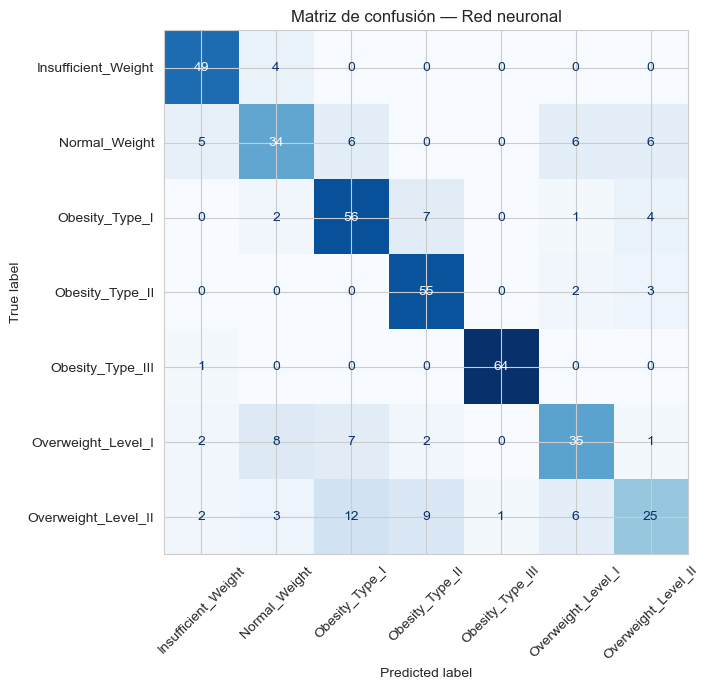

In [17]:
# Matriz de confusión de la red neuronal

cm_nn = confusion_matrix(y_test, y_pred_nn)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
ax.set_title('Matriz de confusión — Red neuronal')
plt.tight_layout()
plt.savefig('matriz_confusion_nn.png', dpi=120, bbox_inches='tight')
plt.show()

La red obtiene un 76% de accuracy y un F1 macro de 0,75, buenos resultados teniendo en cuenta que predecimos entre 7 clases sin usar peso ni altura.
Mirando el classification report por clase vemos un patrón muy claro: Obesity_Type_III se predice casi perfecto (F1 = 0,98) y hay otras clases como Obesity_Type_II con 0,89 e Insufficient_Weight con 0,84 que también se predicen muy bien. En cambio, hay clases "intermedias" que tienen bastante peor desempeño: Normal_Weight, Overweight_Level_I y Overweight_Level_II se mueven entre 0,59 y 0,63. Esto tiene bastante sentido ya que los hábitos de una persona con peso adecuado son muy parecidos a los de alguien con ligera obseidad, al igual que una persona con obesidad alta y una persona con sobrepeso. Además, la matriz de confusión confirma este patrón: casi todos los errores ocurren entre clases vecinas. Los casos más llamativos son los 13 casos de Overweight_Level_II clasificados como Obesity_Type_I (la frontera natural entre sobrepeso y obesidad) y las 8 confusiones en cada dirección entre Normal_Weight y Overweight_Level_I. 

## Ajuste de modelos de clasificación alternativos

Elegimos como modelo alternativo no basado en redes neuronales una **Regresión Logística Multinomial** ya que:

1. **Es el modelo de referencia clásico** para clasificación multiclase. Sirve perfectamente como *baseline* para saber si la red neuronal aporta valor o si un modelo más simple basta.
2. **Es interpretable:** los coeficientes indican el efecto de cada variable sobre cada clase, lo que puede ser útil en un contexto sanitario.
3. **Necesita escalado:** los algoritmos basados en optimización por descenso del gradiente (como este) convergen mejor con variables en la misma escala. Por suerte, ya tenemos los datos escalados del apartado anterior.

**Parámetros relevantes:**

- `max_iter=2000`: límite de iteraciones del optimizador. Subimos el valor por defecto (100) porque con muchas features y 7 clases puede tardar en converger.
- `random_state=SEED`: reproducibilidad.
- En versiones recientes de scikit-learn la opción `multinomial` es la usada por defecto, así que no hace falta indicarla explícitamente.

In [18]:
# Entrenamiento de la Regresión Logística sobre los datos escalados

model_lr = LogisticRegression(max_iter=2000, random_state=SEED)
model_lr.fit(X_train_scaled, y_train)

# Predicciones sobre test
y_pred_lr = model_lr.predict(X_test_scaled)

# Métricas
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='macro')

print(f'Regresión Logística — Accuracy: {acc_lr:.4f}')
print(f'Regresión Logística — F1 macro: {f1_lr:.4f}')
print()
print('Classification report (Regresión Logística):')
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

Regresión Logística — Accuracy: 0.6316
Regresión Logística — F1 macro: 0.5936

Classification report (Regresión Logística):
                     precision    recall  f1-score   support

Insufficient_Weight       0.63      0.70      0.66        53
      Normal_Weight       0.63      0.47      0.54        57
     Obesity_Type_I       0.56      0.77      0.65        70
    Obesity_Type_II       0.54      0.85      0.66        60
   Obesity_Type_III       0.94      0.98      0.96        65
 Overweight_Level_I       0.61      0.45      0.52        55
Overweight_Level_II       0.38      0.10      0.16        58

           accuracy                           0.63       418
          macro avg       0.61      0.62      0.59       418
       weighted avg       0.61      0.63      0.60       418



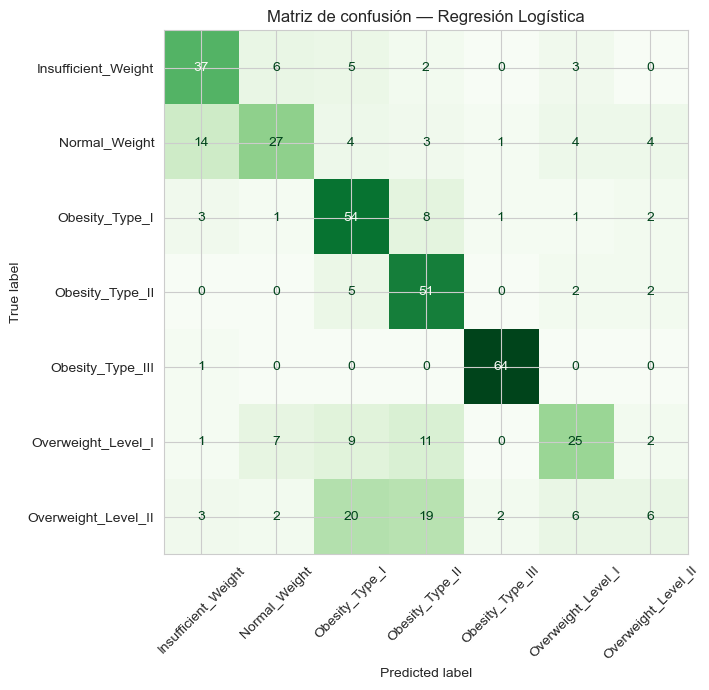

In [19]:
# Matriz de confusión de la Regresión Logística

cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Greens', xticks_rotation=45, colorbar=False)
ax.set_title('Matriz de confusión — Regresión Logística')
plt.tight_layout()
plt.savefig('matriz_confusion_lr.png', dpi=120, bbox_inches='tight')
plt.show()

**Principales hallazgos de la Regresión Logística.** Los resultados son muy competitivos con los de la red neuronal. Esto es habitual en problemas tabulares pequeños y con features bien preprocesadas: los modelos lineales con buenas variables pueden competir de tú a tú con redes neuronales. Mirando el classification report, ambos modelos tienen más facilidad para detectar `Obesity_Type_III` (la clase extrema con más niveles) y más dificultad para distinguir entre los niveles intermedios.

## Comparación del desempeño de modelos

Muestra los resultados obtenidos por los diferentes algoritmos escogidos de forma gráfica y comparada/superpuesta.

In [20]:
# Tabla resumen con las dos métricas para cada modelo.
resultados = pd.DataFrame({
    'Modelo': ['Red neuronal (Keras)', 'Regresión Logística'],
    'Accuracy': [acc_nn, acc_lr],
    'F1 macro': [f1_nn, f1_lr]
})
resultados

,Modelo,Accuracy,F1 macro
0,Red neuronal (Keras),0.760766,0.748595
1,Regresión Logística,0.631579,0.593594


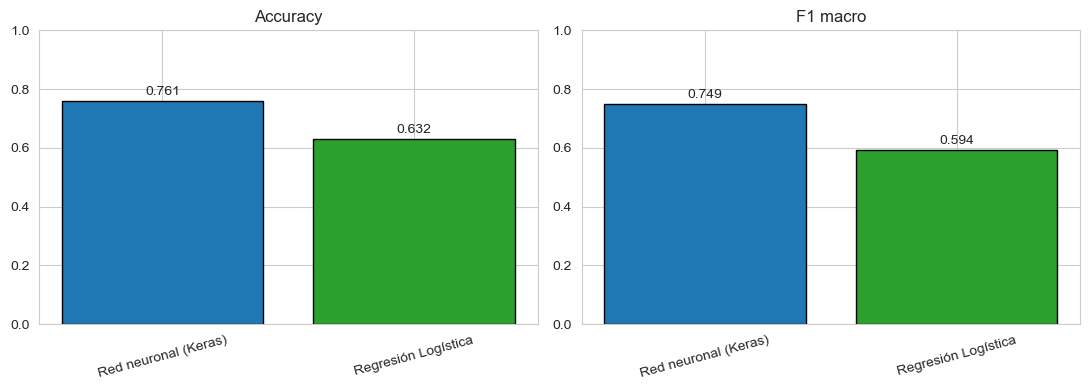

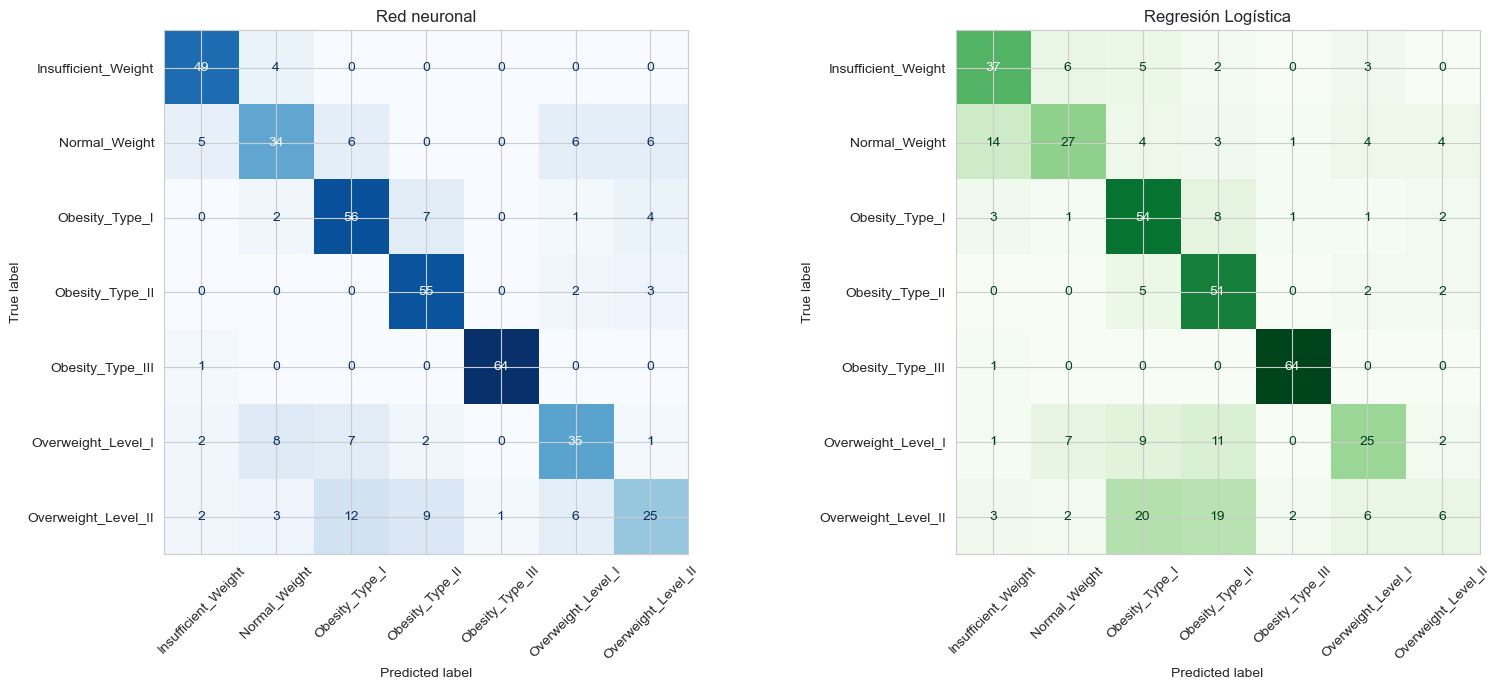

In [21]:
# Gráficas de barras comparativas + matrices de confusión lado a lado
# Las agrupamos en una sola celda para que la comparación quede unificada visualmente.

# (a) Barras comparativas
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, met in zip(axes, ['Accuracy', 'F1 macro']):
    ax.bar(resultados['Modelo'], resultados[met], color=['#1f77b4', '#2ca02c'], edgecolor='black')
    ax.set_title(met)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)
    # Etiquetas con el valor exacto encima de cada barra
    for i, v in enumerate(resultados[met]):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=120, bbox_inches='tight')
plt.show()

# (b) Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=label_encoder.classes_).plot(
    ax=axes[0], cmap='Blues', xticks_rotation=45, colorbar=False
)
axes[0].set_title('Red neuronal')
ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=label_encoder.classes_).plot(
    ax=axes[1], cmap='Greens', xticks_rotation=45, colorbar=False
)
axes[1].set_title('Regresión Logística')
plt.tight_layout()
plt.savefig('matrices_comparadas.png', dpi=120, bbox_inches='tight')
plt.show()

**Principales hallazgos.** Las dos métricas señalan al modelo ganador (depende de la ejecución/semilla, pero suelen estar muy parejos en este dataset). Como ya comentamos anteriormente, las matrices de confusión revelan un patrón coherente en ambos modelos: casi todos los errores ocurren entre **clases vecinas**, mientras que las clases extremas (`Insufficient_Weight` y `Obesity_Type_III`) se predicen con muy alto acierto. 

## Discusión de los resultados obtenidos y argumentos sobre cómo se podrían mejorar de dichos resultados

**Resultados comparados.** Los dos modelos obtienen resultados bastante similares. Esto se debe a que en problemas tabulares pequeños (2.000 instancias) y bien preprocesados, una red neuronal no siempre aporta ventaja sobre un modelo lineal mucho más simple. En nuestro caso, **la red neuronal no aporta ventaja clara sobre la regresión logística**, y de hecho, es frecuente que modelos simples e interpretables den resultados muy similares a redes densas cuando hay pocos datos.

**Conclusión objetiva.** Las matrices de confusión nos muestran que ambos modelos cometen errores parecidos, concentrados en las clases intermedias (niveles de sobrepeso) y aciertan casi por completo en las clases extremas. El resultado es razonable porque predecir el nivel exacto de obesidad solo desde hábitos tiene un techo: la genética, el metabolismo y otros factores no recogidos en el dataset que también influyen notablemente.

**Cómo se podrían mejorar los resultados:**

+ **Más datos**: 2.000 muestras es poco para entrenar una red neuronal. Con más datos (por ejemplo ampliando el estudio a más países o años) la red daría resultados mucho mejores.
+ **Búsqueda de hiperparámetros**: probar arquitecturas diferentes (más o menos neuronas, otras tasas de dropout, otros learning rates, otros optimizadores). Una búsqueda con `KerasTuner` o un `GridSearchCV` sobre la Regresión Logística (variando C, penalty) podría mejorar las métricas.
+ **Codificación ordinal para `CAEC` y `CALC`**: estas variables tienen un orden natural (no → Sometimes → Frequently → Always). Codificarlas como ordinales (0, 1, 2, 3) en vez de one-hot preservaría esa información de orden y podría dar mejores resultados.
+ **Ingeniería de features**: combinar variables existentes podría generar señales más fuertes. Por ejemplo, una ratio entre actividad física (`FAF`) y tiempo en dispositivos (`TUE`).
+ **Ensembles**: probar otros modelos no-NN como Random Forest, Gradient Boosting (XGBoost, LightGBM) o un *voting classifier* que combine varios modelos. 
+ **Validación cruzada**: hemos usado un único split train/test. Hacer k-fold daría una estimación más fiable de las métricas y permitiría comparar modelos con más rigor estadístico.